# Compare Old vs New Metrics

This notebook compares the legacy per-case Dice saved in `outputs/20260304-194354_Unet3D/infer_val_best/eval_val_per_case.csv` against metrics recomputed from `submit.csv` using the new MONAI-based helpers in `src.metrics`.

It does three things:
1. Recomputes the old Dice from the submission file to sanity-check the legacy CSV.
2. Recomputes new metrics (`Dice`, `HD95`, `Precision`, `Recall`) per `case_day`.
3. Merges old/new results and highlights where Dice changes.


In [1]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

REPO_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = next(p.resolve() for p in REPO_CANDIDATES if (p / "src").exists() and (p / "outputs").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.constants import CLASSES, CLASS2IDX
from src.data_utils import build_case_day_slices
from src.metrics import summarize_metrics
from src.rle import rle_decode

RUN_DIR = REPO_ROOT / "outputs/20260304-194354_Unet3D/infer_val_best"
SUBMIT_CSV = RUN_DIR / "submit.csv"
OLD_PER_CASE_CSV = RUN_DIR / "eval_val_per_case.csv"
OLD_SUMMARY_JSON = RUN_DIR / "eval_val_summary.json"
TRAIN_CSV = REPO_ROOT / "inputs/train.csv"
IDS_CSV = REPO_ROOT / "inputs/splits/val_case_days.csv"
TRAIN_DIR = REPO_ROOT / "inputs/train"
OUT_DIR = RUN_DIR / "metric_compare_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# If True, HD95 uses spacing=(1.0, psx, psy) parsed from scan filenames.
# If False, HD95 is reported in voxel units.
USE_XY_SPACING = False

RUN_DIR


PosixPath('/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/20260304-194354_Unet3D/infer_val_best')

In [2]:
CASE_DAY_RE = re.compile(r"^(case\d+_day\d+)_slice_(\d+)$")


def prepare_eval_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    parsed = out["id"].astype(str).str.extract(CASE_DAY_RE)
    out["case_day"] = parsed[0]
    out["slice_idx"] = parsed[1].astype(int)
    out["segmentation"] = out["segmentation"].fillna("")
    return out


def old_dice_per_class(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.float()
    target = target.float()
    dims = tuple(range(1, pred.ndim))
    inter = (pred * target).sum(dim=dims)
    denom = pred.sum(dim=dims) + target.sum(dim=dims)
    return (2.0 * inter + eps) / (denom + eps)


def _parse_spacing_from_slice_path(path: str) -> tuple[float, float]:
    parts = Path(path).stem.split("_")
    if len(parts) >= 6:
        return float(parts[4]), float(parts[5])
    return 1.0, 1.0


def decode_case_volume(
    case_df: pd.DataFrame,
    *,
    slice_to_z: dict[int, int],
    num_slices: int,
    height: int,
    width: int,
) -> np.ndarray:
    volume = np.zeros((len(CLASSES), num_slices, height, width), dtype=np.uint8)
    for row in case_df.to_dict("records"):
        z = slice_to_z[int(row["slice_idx"])]
        c = CLASS2IDX[str(row["class"])]
        volume[c, z] = rle_decode(str(row.get("segmentation", "")), height, width)
    return volume


def compute_case_metrics(
    case_day: str,
    pred_case_df: pd.DataFrame,
    gt_case_df: pd.DataFrame,
    case_day_slices: dict[str, list[str]],
) -> dict[str, float]:
    slice_files = case_day_slices[case_day]
    num_slices = len(slice_files)
    first_parts = Path(slice_files[0]).stem.split("_")
    height = int(first_parts[2])
    width = int(first_parts[3])
    psx, psy = _parse_spacing_from_slice_path(slice_files[0])
    spacing = (1.0, psx, psy) if USE_XY_SPACING else None

    slice_to_z = {}
    for z, path in enumerate(slice_files):
        parts = Path(path).stem.split("_")
        slice_to_z[int(parts[1])] = z

    pred_vol = decode_case_volume(
        pred_case_df,
        slice_to_z=slice_to_z,
        num_slices=num_slices,
        height=height,
        width=width,
    )
    gt_vol = decode_case_volume(
        gt_case_df,
        slice_to_z=slice_to_z,
        num_slices=num_slices,
        height=height,
        width=width,
    )

    pred_t = torch.from_numpy(pred_vol).float()
    gt_t = torch.from_numpy(gt_vol).float()
    legacy_dice = old_dice_per_class(pred_t, gt_t)
    new_summary = summarize_metrics(
        pred_t.unsqueeze(0),
        gt_t.unsqueeze(0),
        class_names=CLASSES,
        spacing=spacing,
    )

    row = {
        "case_day": case_day,
        "num_slices": int(num_slices),
        "legacy_dice_mean": float(legacy_dice.mean().item()),
    }
    for idx, name in enumerate(CLASSES):
        row[f"legacy_dice_{name}"] = float(legacy_dice[idx].item())
    for key, value in new_summary.items():
        row[f"new_{key}"] = float(value)
    return row


In [3]:
old_per_case = pd.read_csv(OLD_PER_CASE_CSV)
old_summary = json.loads(OLD_SUMMARY_JSON.read_text())

pred_df = prepare_eval_frame(pd.read_csv(SUBMIT_CSV))
gt_df = prepare_eval_frame(pd.read_csv(TRAIN_CSV, usecols=["id", "class", "segmentation"]))
val_case_days = pd.read_csv(IDS_CSV)["case_day"].astype(str).tolist()
case_day_slices = build_case_day_slices(str(TRAIN_DIR))

pred_df = pred_df[pred_df["case_day"].isin(val_case_days)].copy()
gt_df = gt_df[gt_df["case_day"].isin(val_case_days)].copy()

print(f"Legacy eval cases: {len(old_per_case)}")
print(f"Prediction rows   : {len(pred_df)}")
print(f"GT rows           : {len(gt_df)}")
print(f"Tracked classes   : {CLASSES}")
display(old_per_case.head())
old_summary


Legacy eval cases: 58
Prediction rows   : 24864
GT rows           : 24864
Tracked classes   : ['large_bowel', 'small_bowel', 'stomach']


,case_day,dice_mean,dice_large_bowel,dice_small_bowel,dice_stomach,num_slices
0,case122_day0,0.832064,0.829519,0.750219,0.916455,144
1,case122_day18,0.855543,0.824688,0.805267,0.936674,144
2,case122_day24,0.829246,0.833884,0.738127,0.915725,144
3,case122_day25,0.880396,0.894478,0.805634,0.941077,144
4,case122_day27,0.819973,0.808316,0.715286,0.936317,144


{'data_root': '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/inputs',
 'train_csv': '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/inputs/train.csv',
 'weights': '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/20260304-194354_Unet3D/best.pt',
 'ids_csv': '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/inputs/splits/val_case_days.csv',
 'num_case_days': 58,
 'mean_dice': 0.7658376547497938,
 'mean_dice_per_class': [0.7664814154651706,
  0.682214832318754,
  0.8488167164654568],
 'threshold': 0.5,
 'roi_size': [96, 224, 224],
 'sw_batch_size': 2,
 'overlap': 0.25}

In [4]:
pred_groups = {k: v.copy() for k, v in pred_df.groupby("case_day", sort=False)}
gt_groups = {k: v.copy() for k, v in gt_df.groupby("case_day", sort=False)}

rows = []
missing = []
for i, case_day in enumerate(val_case_days, start=1):
    if case_day not in pred_groups or case_day not in gt_groups or case_day not in case_day_slices:
        missing.append(case_day)
        continue
    rows.append(compute_case_metrics(case_day, pred_groups[case_day], gt_groups[case_day], case_day_slices))
    if i % 10 == 0:
        print(f"Processed {i}/{len(val_case_days)} case_days")

compare_df = pd.DataFrame(rows).sort_values("case_day").reset_index(drop=True)
print(f"Computed cases: {len(compare_df)}")
print(f"Missing cases : {len(missing)}")
if missing:
    display(pd.Series(missing, name="missing_case_day"))
display(compare_df.head())


<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarnin

Processed 10/58 case_days


/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_

Processed 20/58 case_days


/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_

...

/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_

Processed 50/58 case_days


/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/jeremiah/miniconda/envs/uwgi/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_

Computed cases: 58
Missing cases : 0


,case_day,num_slices,legacy_dice_mean,legacy_dice_large_bowel,legacy_dice_small_bowel,legacy_dice_stomach,new_dice_mean,new_precision_mean,new_recall_mean,new_hd95_mean,...,new_recall_large_bowel,new_hd95_large_bowel,new_dice_small_bowel,new_precision_small_bowel,new_recall_small_bowel,new_hd95_small_bowel,new_dice_stomach,new_precision_stomach,new_recall_stomach,new_hd95_stomach
0,case122_day0,144,0.832064,0.829519,0.750219,0.916455,0.832064,0.826386,0.854875,4.534109,...,0.788114,8.602325,0.750219,0.642995,0.900362,4.000000,0.916455,0.960648,0.876148,1.000000
1,case122_day18,144,0.855543,0.824688,0.805267,0.936674,0.855543,0.846668,0.869371,11.933940,...,0.782644,27.477262,0.805267,0.747954,0.872091,6.324555,0.936674,0.920545,0.953378,2.000000
2,case122_day24,144,0.829246,0.833884,0.738127,0.915725,0.829246,0.804729,0.867550,12.814208,...,0.790779,24.000000,0.738127,0.640568,0.870744,12.206555,0.915725,0.891658,0.941127,2.236068
3,case122_day25,144,0.880396,0.894478,0.805634,0.941077,0.880396,0.857871,0.905280,2.913886,...,0.932268,3.000000,0.805634,0.767161,0.848168,3.741657,0.941077,0.946820,0.935403,2.000000
4,case122_day27,144,0.819973,0.808316,0.715286,0.936317,0.819973,0.812599,0.837942,11.158795,...,0.756309,14.035668,0.715286,0.633710,0.820967,17.204651,0.936317,0.936085,0.936549,2.236068


In [5]:
merged = old_per_case.merge(compare_df, on=["case_day", "num_slices"], how="inner", validate="one_to_one")

dice_cols = ["dice_mean", *[f"dice_{name}" for name in CLASSES]]
for col in dice_cols:
    merged[f"delta_legacy_recomputed__{col}"] = merged[f"legacy_{col}"] - merged[col]
    merged[f"delta_new_monai__{col}"] = merged[f"new_{col}"] - merged[col]

compare_cols = [
    "case_day",
    "dice_mean",
    "legacy_dice_mean",
    "new_dice_mean",
    "delta_legacy_recomputed__dice_mean",
    "delta_new_monai__dice_mean",
    "new_precision_mean",
    "new_recall_mean",
    "new_hd95_mean",
]
display(merged[compare_cols].head())


,case_day,dice_mean,legacy_dice_mean,new_dice_mean,delta_legacy_recomputed__dice_mean,delta_new_monai__dice_mean,new_precision_mean,new_recall_mean,new_hd95_mean
0,case122_day0,0.832064,0.832064,0.832064,5.960464e-08,5.960464e-08,0.826386,0.854875,4.534109
1,case122_day18,0.855543,0.855543,0.855543,0.000000e+00,0.000000e+00,0.846668,0.869371,11.933940
2,case122_day24,0.829246,0.829246,0.829246,0.000000e+00,0.000000e+00,0.804729,0.867550,12.814208
3,case122_day25,0.880396,0.880396,0.880396,-5.960464e-08,-5.960464e-08,0.857871,0.905280,2.913886
4,case122_day27,0.819973,0.819973,0.819973,-5.960464e-08,-5.960464e-08,0.812599,0.837942,11.158795


In [6]:
dice_summary_rows = []
for col in dice_cols:
    delta_col = f"delta_new_monai__{col}"
    legacy_delta_col = f"delta_legacy_recomputed__{col}"
    dice_summary_rows.append(
        {
            "metric": col,
            "old_csv_mean": float(merged[col].mean()),
            "legacy_recomputed_mean": float(merged[f"legacy_{col}"].mean()),
            "new_monai_mean": float(merged[f"new_{col}"].mean()),
            "legacy_abs_delta_max": float(merged[legacy_delta_col].abs().max()),
            "new_abs_delta_max": float(merged[delta_col].abs().max()),
            "new_abs_delta_mean": float(merged[delta_col].abs().mean()),
            "new_num_nonzero_delta": int((merged[delta_col].abs() > 1e-8).sum()),
        }
    )

dice_summary_df = pd.DataFrame(dice_summary_rows)
extra_metric_df = compare_df[["new_precision_mean", "new_recall_mean", "new_hd95_mean"]].agg(["mean", "median", "min", "max"]).T

display(dice_summary_df)
display(extra_metric_df)


,metric,old_csv_mean,legacy_recomputed_mean,new_monai_mean,legacy_abs_delta_max,new_abs_delta_max,new_abs_delta_mean,new_num_nonzero_delta
0,dice_mean,0.765838,0.756010,0.756010,0.570019,0.570019,0.009828,18
1,dice_large_bowel,0.766481,0.756566,0.756566,0.575078,0.575078,0.009915,1
2,dice_small_bowel,0.682215,0.673305,0.673305,0.516794,0.516794,0.008910,1
3,dice_stomach,0.848817,0.838158,0.838158,0.618186,0.618186,0.010658,1


,mean,median,min,max
new_precision_mean,0.771262,0.814401,0.112472,0.926607
new_recall_mean,0.767246,0.795854,0.134832,0.935448
new_hd95_mean,9.841504,8.600680,1.666667,31.999731


In [7]:
worst_dice_delta = merged.sort_values("delta_new_monai__dice_mean", key=lambda s: s.abs(), ascending=False).head(20)
worst_hd95 = merged.sort_values("new_hd95_mean", ascending=False).head(20)

display(
    worst_dice_delta[
        [
            "case_day",
            "dice_mean",
            "new_dice_mean",
            "delta_new_monai__dice_mean",
            "new_precision_mean",
            "new_recall_mean",
            "new_hd95_mean",
        ]
    ]
)

display(
    worst_hd95[
        [
            "case_day",
            "new_hd95_mean",
            "new_dice_mean",
            "new_precision_mean",
            "new_recall_mean",
        ]
    ]
)


,case_day,dice_mean,new_dice_mean,delta_new_monai__dice_mean,new_precision_mean,new_recall_mean,new_hd95_mean
57,case89_day21,0.848783,0.278764,-5.700195e-01,0.277445,0.282331,9.739848
39,case44_day20,0.718349,0.718349,-1.192093e-07,0.692883,0.778749,12.457377
40,case53_day0,0.824474,0.824474,-1.192093e-07,0.840407,0.810783,6.718752
42,case65_day25,0.860007,0.860007,-1.192093e-07,0.892605,0.829755,7.073397
13,case138_day0,0.594040,0.594040,-5.960464e-08,0.534685,0.824324,17.792093
22,case154_day0,0.854315,0.854315,-5.960464e-08,0.831442,0.885033,6.333333
4,case122_day27,0.819973,0.819973,-5.960464e-08,0.812599,0.837942,11.158795
19,case145_day0,0.860939,0.860939,5.960464e-08,0.834631,0.889720,1.895186
0,case122_day0,0.832064,0.832064,5.960464e-08,0.826386,0.854875,4.534109
3,case122_day25,0.880396,0.880396,-5.960464e-08,0.857871,0.905280,2.913886


,case_day,new_hd95_mean,new_dice_mean,new_precision_mean,new_recall_mean
49,case77_day20,31.999731,0.597181,0.624609,0.586533
50,case7_day0,25.201086,0.119605,0.112472,0.134832
48,case77_day18,24.807060,0.743889,0.750144,0.750810
27,case30_day0,23.337614,0.612152,0.761896,0.538175
12,case130_day22,19.750959,0.785443,0.809236,0.764724
11,case130_day20,18.623436,0.734434,0.780832,0.698176
13,case138_day0,17.792093,0.594040,0.534685,0.824324
16,case142_day0,15.919583,0.725175,0.740124,0.743231
32,case43_day0,15.373487,0.707583,0.829732,0.645541
56,case89_day20,12.897514,0.707044,0.652596,0.842713


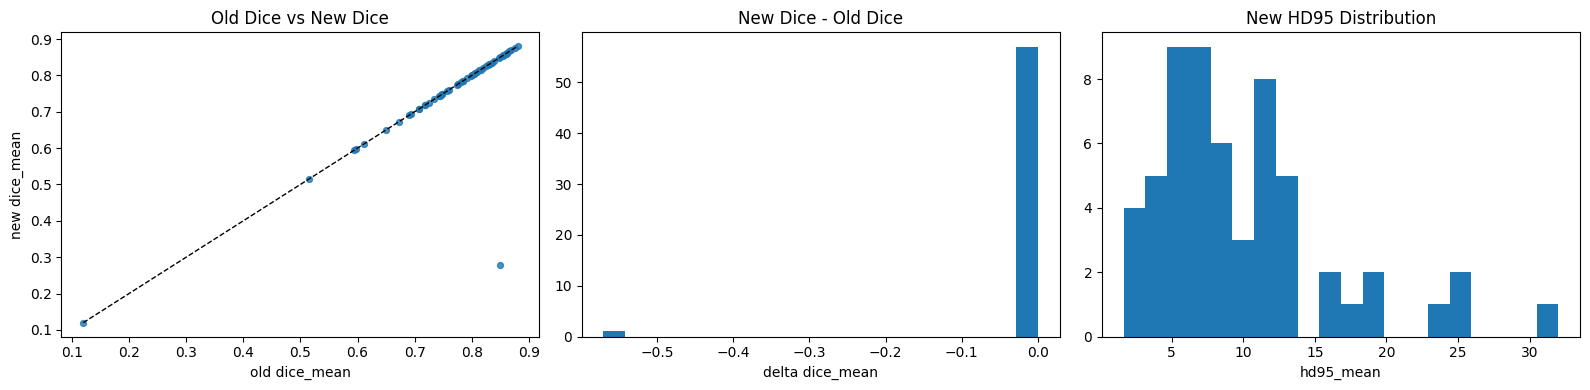

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(merged["dice_mean"], merged["new_dice_mean"], s=18, alpha=0.8)
axes[0].set_title("Old Dice vs New Dice")
axes[0].set_xlabel("old dice_mean")
axes[0].set_ylabel("new dice_mean")
lo = float(min(merged["dice_mean"].min(), merged["new_dice_mean"].min()))
hi = float(max(merged["dice_mean"].max(), merged["new_dice_mean"].max()))
axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)

axes[1].hist(merged["delta_new_monai__dice_mean"], bins=20)
axes[1].set_title("New Dice - Old Dice")
axes[1].set_xlabel("delta dice_mean")

finite_hd95 = compare_df.loc[np.isfinite(compare_df["new_hd95_mean"]), "new_hd95_mean"]
axes[2].hist(finite_hd95, bins=20)
axes[2].set_title("New HD95 Distribution")
axes[2].set_xlabel("hd95_mean")

plt.tight_layout()
plt.show()


In [9]:
compare_csv = OUT_DIR / "per_case_metric_compare.csv"
summary_json = OUT_DIR / "metric_compare_summary.json"

merged.to_csv(compare_csv, index=False)
payload = {
    "run_dir": str(RUN_DIR),
    "use_xy_spacing": bool(USE_XY_SPACING),
    "num_cases": int(len(merged)),
    "old_eval_summary": old_summary,
    "dice_abs_delta_mean": float(merged["delta_new_monai__dice_mean"].abs().mean()),
    "dice_abs_delta_max": float(merged["delta_new_monai__dice_mean"].abs().max()),
    "legacy_recomputed_abs_delta_max": float(merged["delta_legacy_recomputed__dice_mean"].abs().max()),
    "mean_new_precision": float(compare_df["new_precision_mean"].mean()),
    "mean_new_recall": float(compare_df["new_recall_mean"].mean()),
    "mean_new_hd95": float(compare_df.loc[np.isfinite(compare_df["new_hd95_mean"]), "new_hd95_mean"].mean()),
}
summary_json.write_text(json.dumps(payload, indent=2) + "\n", encoding="utf-8")

print(compare_csv)
print(summary_json)


/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/20260304-194354_Unet3D/infer_val_best/metric_compare_notebook/per_case_metric_compare.csv
/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/20260304-194354_Unet3D/infer_val_best/metric_compare_notebook/metric_compare_summary.json
